# EDA — PUBG Finish Placement Prediction

> Разведочный анализ для проекта *PUBG Placement Predictor + Drift Monitoring*.

## Оглавление

1. [Постановка задачи](#s1)
2. [Настройки окружения](#s2)
3. [Обзор данных и пропуски](#s3)
4. [Режимы матчей](#s4)
5. [Распределения фич](#s5)
6. [Аномалии и читеры](#s6)
7. [Утечка killPlace](#s7)
8. [Сетка таргета](#s8)
9. [Производные фичи](#s9)
10. [Baseline: без фич vs с фичами](#s10)
11. [Важность фич](#s11)
12. [Отбор фич](#s12)
13. [Итоговая схема IN / OUT](#s13)
14. [Дрейф: постановка мониторинга](#s14)

In [20]:
import pandas as pd
import numpy  as np
from pathlib  import Path

import matplotlib.pyplot as plt
import lightgbm          as lgb
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics         import mean_absolute_error

SEED = 1

<a id="s1"></a>
## 1. Постановка задачи

**Задача.** Регрессия: предсказать `winPlacePerc` [0, 1] — нормированное финальное
место игрока в матче (1 — победа, 0 — последнее место). Метрика - MAE.

**Данные.** Kaggle *PUBG Finish Placement Prediction*, `train_V2.csv`.
Одна строка = агрегированная статистика одного игрока за один матч.

<a id="s2"></a>
## 2. Настройки окружения

In [21]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name in {"research", "notebooks"} else Path.cwd()
RAW_DIR      = PROJECT_ROOT / "data" / "raw"
TRAIN_PATH   = RAW_DIR / "train_V2.csv"

<a id="s3"></a>
## 3. Обзор данных и пропуски

In [22]:
df = pd.read_csv(TRAIN_PATH)
df.head()

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
0,7f96b2f878858a,4d4b580de459be,a10357fd1a4a91,0,0,0.00,0,0,0,60,...,0,0.0000,0,0.00,0,0,244.80,1,1466,0.4444
1,eef90569b9d03c,684d5656442f9e,aeb375fc57110c,0,0,91.47,0,0,0,57,...,0,0.0045,0,11.04,0,0,1434.00,5,0,0.6400
2,1eaf90ac73de72,6a4a42c3245a74,110163d8bb94ae,1,0,68.00,0,0,0,47,...,0,0.0000,0,0.00,0,0,161.80,2,0,0.7755
3,4616d365dd2853,a930a9c79cd721,f1f1f4ef412d7e,0,0,32.90,0,0,0,75,...,0,0.0000,0,0.00,0,0,202.70,3,0,0.1667
4,315c96c26c9aac,de04010b3458dd,6dc8ff871e21e6,0,0,100.00,0,0,0,45,...,0,0.0000,0,0.00,0,0,49.75,2,0,0.1875


In [23]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4446966 entries, 0 to 4446965
Data columns (total 29 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   Id               4446966 non-null  object 
 1   groupId          4446966 non-null  object 
 2   matchId          4446966 non-null  object 
 3   assists          4446966 non-null  int64  
 4   boosts           4446966 non-null  int64  
 5   damageDealt      4446966 non-null  float64
 6   DBNOs            4446966 non-null  int64  
 7   headshotKills    4446966 non-null  int64  
 8   heals            4446966 non-null  int64  
 9   killPlace        4446966 non-null  int64  
 10  killPoints       4446966 non-null  int64  
 11  kills            4446966 non-null  int64  
 12  killStreaks      4446966 non-null  int64  
 13  longestKill      4446966 non-null  float64
 14  matchDuration    4446966 non-null  int64  
 15  matchType        4446966 non-null  object 
 16  maxPlace         4

In [24]:
# Дубли строк по Id
print("дубли по Id:", int(df["Id"].duplicated().sum()))

дубли по Id: 0


**Один пропуск `winPlacePerc`.** Это единственный матч из одного игрока: при `maxPlace = 1`
таргет `winPlacePerc = (maxPlace − winPlace)/(maxPlace − 1)` = деление на 0 -> `NaN`.
Строка нерепрезентативна (матч без соперников) — выбрасываем. Тот же фильтр `maxPlace > 1`
стоит в `reference.build_reference`.

In [25]:
df = df.dropna(subset=["winPlacePerc"])

<a id="s4"></a>
## 4. Режимы матчей

Live-данные - ranked squad fpp на больших картах, сопоставимый режим в датасете - squad-fpp, обе выборки фильтруются до него

In [26]:
df["matchType"].value_counts()

matchType
squad-fpp           1756186
duo-fpp              996691
squad                626526
solo-fpp             536761
duo                  313591
solo                 181943
normal-squad-fpp      17174
crashfpp               6287
normal-duo-fpp         5489
flaretpp               2505
normal-solo-fpp        1682
flarefpp                718
normal-squad            516
crashtpp                371
normal-solo             326
normal-duo              199
Name: count, dtype: int64

In [27]:
df = df[df["matchType"] == 'squad-fpp']
df.shape


(1756186, 29)

<a id="s5"></a>
## 5. Распределения фич

Смотрим распределения таргета и ключевых фич, прежде чем принимать решения.

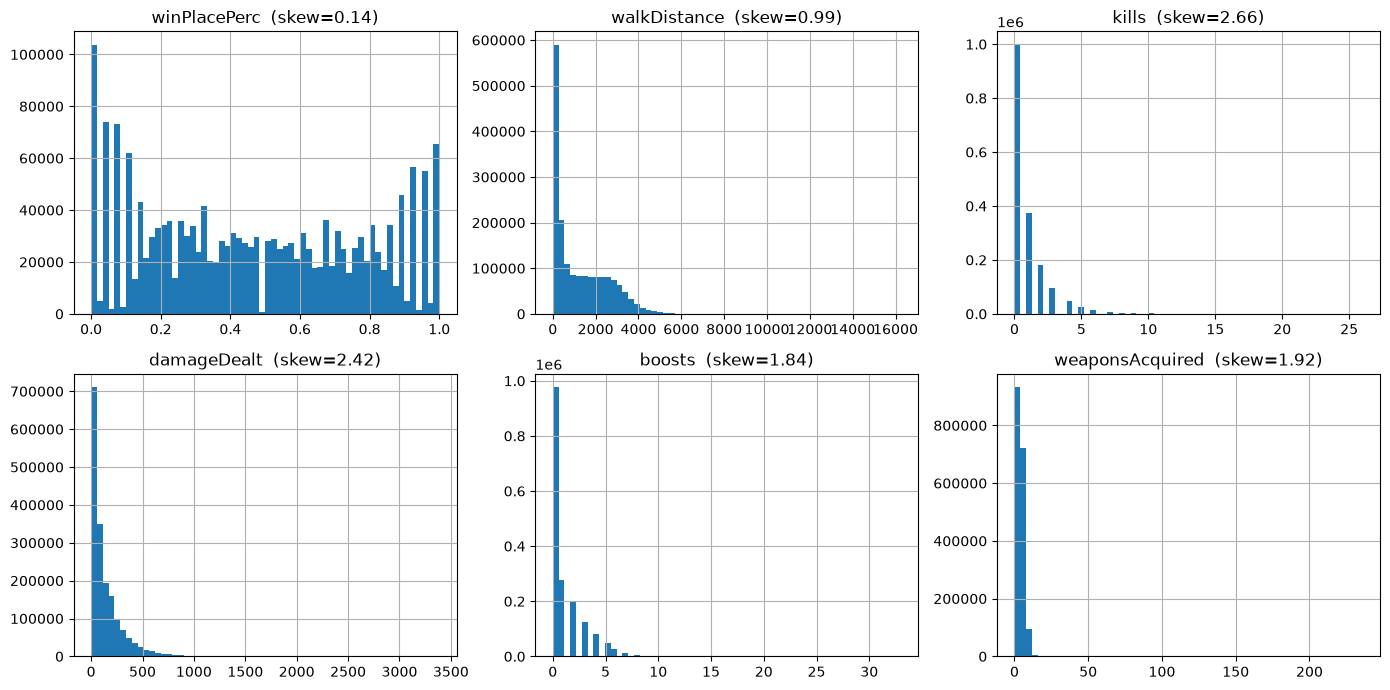

In [28]:
# Распределение таргета и ключевых фич (+ скошенность)
cols = ['winPlacePerc', 'walkDistance', 'kills', 'damageDealt', 'boosts', 'weaponsAcquired']
fig, ax = plt.subplots(2, 3, figsize=(14, 7))
for a, c in zip(ax.ravel(), cols):
    df[c].hist(bins=60, ax=a)
    a.set_title(f'{c}  (skew={df[c].skew():.2f})')
plt.tight_layout(); plt.show()

**Вывод.** Таргет примерно равномерный на [0, 1] — предсказание среднего заведомо плохо.
Боевые фичи сильно скошены вправо: длинные хвосты — редкие матчи или читеры.

<a id="s6"></a>
## 6. Аномалии и читеры

Хвосты — это либо легитимные исключительные матчи, либо читеры. Сначала смотрим, где заканчивается
нормальный хвост (boxplot + перцентили), по этим значениям выставляем пороги для подсчёта подозрительных.

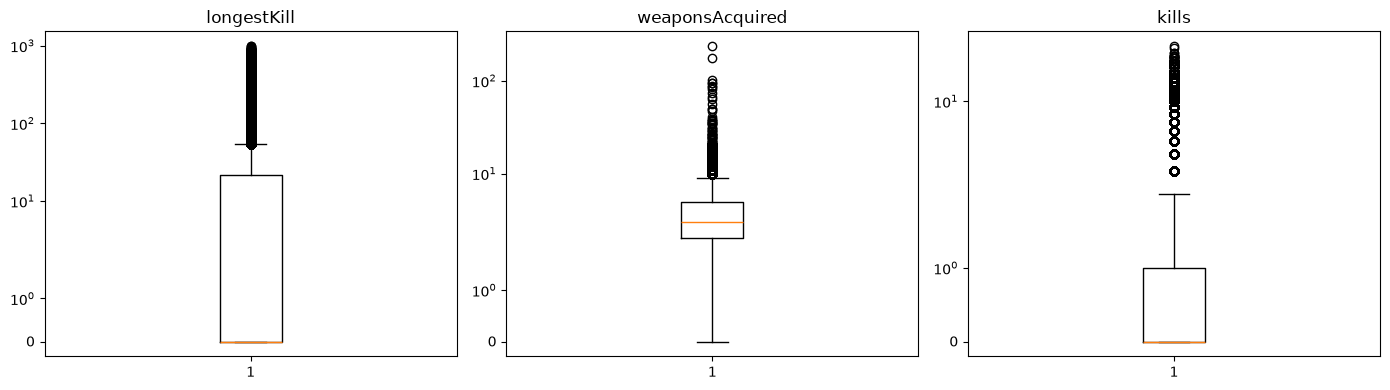

        longestKill  weaponsAcquired  kills
0.9900       249.00             10.0    7.0
0.9990       413.10             13.0   11.0
0.9999       610.15             17.0   15.0


In [29]:
# Boxplot'ы под пороги аномалий (symlog — длинные хвосты)
box = ['longestKill', 'weaponsAcquired', 'kills']
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for a, c in zip(ax, box):
    a.boxplot(df[c], showfliers=True)
    a.set_title(c); a.set_yscale('symlog')
plt.tight_layout(); plt.show()

# Где заканчивается хвост — пороги лежат далеко за 99.99-перцентилем
print(df[box].quantile([0.99, 0.999, 0.9999]).round(2))

**Наблюдение.** 99.99-й перцентиль: `longestKill = 610 м`, `weaponsAcquired = 17`, `kills = 15`.
Всё заметно выше — вне правдоподобного диапазона squad-fpp. Ставим пороги чуть выше 99.99-перцентиля,
чтобы ловить физически невозможное, и считаем долю читеров.

In [30]:
total_dist = df['walkDistance'] + df['rideDistance'] + df['swimDistance']

# Пороги выставлены по хвостам из boxplot (чуть выше 99.99-перцентиля)
anomalies = {
    "Убийства без перемещения":       (df['kills'] > 0) & (total_dist == 0),
    "100% headshot при kills >= 10":  (df['kills'] >= 10) & (df['headshotKills'] == df['kills']),
    "Убийства с расстояния > 700 м":  (df['longestKill'] > 700),
    "Подобрано оружия > 20":          (df['weaponsAcquired'] > 20),
    "Аномально много убийств > 20":   (df['kills'] > 20),
}

report = pd.DataFrame({
    "строк": {k: int(m.sum())           for k, m in anomalies.items()},
    "доля%": {k: round(100*m.mean(), 4) for k, m in anomalies.items()}
})
print(report.sort_values("строк", ascending=False))

# Уникальные подозрительные — без двойного счёта пересекающихся правил
susp = pd.concat(anomalies.values(), axis=1).any(axis=1)
print(f'\nУникальных подозрительных игроков: {int(susp.sum())} ({round(100*susp.mean(), 3)}%)')

                               строк   доля%
Убийства с расстояния > 700 м     65  0.0037
Подобрано оружия > 20             63  0.0036
Убийства без перемещения          26  0.0015
Аномально много убийств > 20      14  0.0008
100% headshot при kills >= 10      6  0.0003

Уникальных подозрительных игроков: 172 (0.01%)


**Вывод.** Доля читеров — доли процента. Строки не удаляем — только фиксируем оценку доли.

<a id="s7"></a>
## 7. Утечка `killPlace`

`killPlace` — ранг по числу убийств; при равенстве тай-брейк по порядку выбывания → кодирует таргет. Проверяем корреляцией:

In [31]:
zero_kills = df[df['kills'] == 0]
corr_all = df['killPlace'].corr(df['winPlacePerc'])
corr_zero = zero_kills['killPlace'].corr(zero_kills['winPlacePerc'])
print(f'все игроки:  {corr_all}')
print(f'с 0 убийств: {corr_zero}')


все игроки:  -0.6962698860204445
с 0 убийств: -0.9388873053018071


при нуле убийств почти идеальная корреляция с `killPlace`

Вывод: `killPlace` исключаем из фич, как и `rankPoints`, `killPoints`, `winPoints` - в современном api их нет

In [32]:
df = df.drop(['killPlace', 'rankPoints', 'killPoints', 'winPoints'], axis = 1)
df.shape


(1756186, 25)

<a id="s8"></a>
## 8. Сетка таргета

`winPlacePerc = (maxPlace − winPlace)/(maxPlace − 1)` — таргет квантован шагом `1/(maxPlace − 1)`.
Проверяем и снапим предсказания к этой сетке на постпроцессинге.

In [33]:
# Берём один матч
match  = df[df["matchId"] == df["matchId"].iloc[0]]
m      = match["maxPlace"].iloc[0]
places = np.sort(match["winPlacePerc"].unique())

# Индексы должны быть целыми (в пределах погрешности)
k = places * (m - 1)

print("maxPlace:", m)
print(np.round(k, 6))


maxPlace: 28
[ 0.      0.999   2.0007  2.9997  3.9987  5.0004  5.9994  7.0011  8.0001
  8.9991 10.0008 10.9998 11.9988 13.0005 13.9995 15.0012 16.0002 16.9992
 19.9989 21.0006 21.9996 23.0013 24.0003 24.9993 26.001  27.    ]


подтверждено

<a id="s9"></a>
## 9. Производные фичи: match/group-relative

`winPlacePerc` — это перцентиль игрока внутри матча. Абсолютный `walkDistance = 2000` сам по себе ничего
не значит, нужны фичи, выражающие положение относительно своего матча и группы:

- **`*MatchRank`** — процентильный ранг стата внутри матча;
- **`*MatchNorm`** — стат / среднее по матчу;
- **`*GroupMean` / `*GroupRank`** — агрегаты по группе и её ранг в матче.

Ранги берут нейтральный тай-брейк (`average`) и не кодируют порядок выбывания — в отличие от `killPlace`.

Место делит вся команда — таргет обязан быть постоянным внутри `groupId`. Проверяем:

In [34]:
# Таргет константен внутри (matchId, groupId)?
g = df.groupby(["matchId", "groupId"])["winPlacePerc"].nunique()
print("групп:", len(g), "| с непостоянным таргетом:", int((g > 1).sum()))
print("строк на группу:", round(len(df) / len(g), 2))

групп: 506161 | с непостоянным таргетом: 0
строк на группу: 3.47


Таргет постоянен внутри группы, задача по сути групповая. Модель оставляем player-level (снап к сетке идёт по игрокам), но групповые фичи потому и доминируют. `GroupRank` считается по игрокам, то есть взвешен размером группы — принятое упрощение.

In [35]:
# Кандидаты: полный набор match/group-relative фич (по всем боевым/движковым статам)
RANK_STATS  = ['walkDistance','kills','damageDealt','boosts','heals','weaponsAcquired',
               'longestKill','DBNOs','rideDistance','killStreaks']
NORM_STATS  = ['walkDistance','kills','damageDealt']
GROUP_STATS = ['walkDistance','kills','damageDealt','boosts','weaponsAcquired','longestKill']

# Ранги в матче, нормировки на среднее матча, агрегаты по группе (тиммейты делят место)
def build_candidates(d):
    d = d.copy()
    g = d.groupby('matchId')
    d['playersInMatch'] = g['matchId'].transform('size')
    for s in RANK_STATS: d[f'{s}MatchRank'] = g[s].rank(pct=True)
    for s in NORM_STATS: d[f'{s}MatchNorm'] = d[s] / (g[s].transform('mean') + 1e-9)
    gg = d.groupby(['matchId','groupId'])
    d['groupSize'] = gg['matchId'].transform('size')
    for s in GROUP_STATS:
        gm = gg[s].transform('mean')
        d[f'{s}GroupMean'] = gm
        d[f'{s}GroupRank'] = gm.groupby(d['matchId']).rank(pct=True)
    return d

CAND = ([f'{s}MatchRank' for s in RANK_STATS] + [f'{s}MatchNorm' for s in NORM_STATS]
        + [f'{s}GroupMean' for s in GROUP_STATS] + [f'{s}GroupRank' for s in GROUP_STATS]
        + ['playersInMatch','groupSize'])

dff = build_candidates(df)
print('кандидатов derived:', len(CAND))
dff[['matchId','groupId','walkDistance','walkDistanceGroupMean','walkDistanceGroupRank']].head()

кандидатов derived: 27


,matchId,groupId,walkDistance,walkDistanceGroupMean,walkDistanceGroupRank
0,a10357fd1a4a91,4d4b580de459be,244.8,182.990000,0.411458
1,aeb375fc57110c,684d5656442f9e,1434.0,1892.750000,0.609890
3,f1f1f4ef412d7e,a930a9c79cd721,202.7,202.700000,0.153846
5,bac52627a12114,289a6836a88d27,34.7,50.581300,0.110526
6,a8274e903927a2,2c485a1ad3d0f1,13.5,23.411667,0.036082


<a id="s10"></a>
## 10. Baseline: без производных фич vs с ними

Сплит строго по `matchId` (строки одного матча взаимозависимы). Сначала тривиальный пол — среднее, затем сравнение raw vs derived на `GroupKFold`.

In [36]:
TARGET = "winPlacePerc"

# Тривиальный пол: предсказываем глобальное среднее
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
tr_idx, va_idx = next(splitter.split(dff, groups=dff["matchId"]))
train, val = dff.iloc[tr_idx], dff.iloc[va_idx]
mae_mean = mean_absolute_error(val[TARGET], np.full(len(val), train[TARGET].mean()))
print(f'MAE среднего (пол): {mae_mean:.5f}')

MAE среднего (пол): 0.27203


Теперь набор сырых фич против «сырые + производные» (метрика — MAE после снапа к сетке).

In [37]:
# Все сырые фичи (для честного сравнения «до»)
RAW  = ['walkDistance','rideDistance','kills','damageDealt','boosts','heals','weaponsAcquired',
        'longestKill','DBNOs','killStreaks','matchDuration','swimDistance','assists','headshotKills',
        'revives','roadKills','teamKills','vehicleDestroys']
FULL = RAW + CAND

# Снап предсказания к сетке таргета
def snap(p, mp):
    steps = np.maximum(mp.astype(float) - 1, 1)
    return np.round(np.clip(p, 0, 1) * steps) / steps

# MAE по GroupKFold; early stopping на под-сплите train, не на скоринг-фолде (без утечки в число деревьев)
def cv_mae(feats, n=3):
    maes = []
    for tr, va in GroupKFold(n).split(dff, groups=dff["matchId"]):
        t, v = dff.iloc[tr], dff.iloc[va]
        fit_idx, es_idx = next(GroupShuffleSplit(1, test_size=0.2, random_state=SEED).split(t, groups=t["matchId"]))
        fit, es = t.iloc[fit_idx], t.iloc[es_idx]
        m = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, random_state=SEED, verbose=-1, n_jobs=-1)
        m.fit(fit[feats], fit[TARGET], eval_X=es[feats], eval_y=es[TARGET], eval_metric="l1",
              callbacks=[lgb.early_stopping(50, verbose=False)])
        maes.append(mean_absolute_error(v[TARGET], snap(m.predict(v[feats]), v["maxPlace"].to_numpy())))
    return np.mean(maes)

mae_raw  = cv_mae(RAW)
mae_full = cv_mae(FULL)
print(f'GroupKFold MAE  raw-only  ({len(RAW):>2}): {mae_raw:.5f}')
print(f'GroupKFold MAE  +derived  ({len(FULL):>2}): {mae_full:.5f}   ({(1-mae_full/mae_raw)*100:.1f}% лучше)')

GroupKFold MAE  raw-only  (18): 0.09846
GroupKFold MAE  +derived  (45): 0.05814   (41.0% лучше)


**Вывод.** Производные фичи роняют MAE 0.098 -> 0.058 (−41%). Дальше смотрим, какие из них реально работают.

<a id="s11"></a>
## 11. Важность фич

`feature_importances_` (gain) модели на полном наборе — на чём модель реально держится.

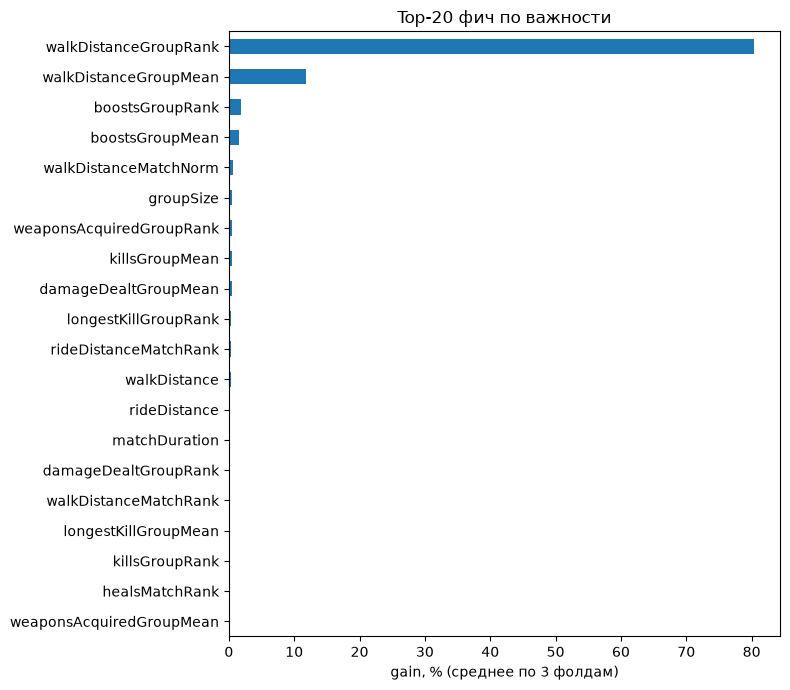

walkDistanceGroupRank       80.32
walkDistanceGroupMean       11.82
boostsGroupRank              1.92
boostsGroupMean              1.60
walkDistanceMatchNorm        0.63
groupSize                    0.53
weaponsAcquiredGroupRank     0.46
killsGroupMean               0.46
damageDealtGroupMean         0.41
longestKillGroupRank         0.29
rideDistanceMatchRank        0.28
walkDistance                 0.26
rideDistance                 0.17
matchDuration                0.16
damageDealtGroupRank         0.16
dtype: float64


In [38]:
# Важности усредняем по 3 фолдам — на одном фолде gain шумит, особенно между коррелированными фичами
imps = []
for tr, va in GroupKFold(3).split(dff, groups=dff["matchId"]):
    t, v = dff.iloc[tr], dff.iloc[va]
    m = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, random_state=SEED, verbose=-1, n_jobs=-1)
    m.fit(t[FULL], t[TARGET], eval_X=v[FULL], eval_y=v[TARGET], eval_metric="l1",
          callbacks=[lgb.early_stopping(50, verbose=False)])
    imps.append(m.booster_.feature_importance("gain"))

gain = np.mean(imps, axis=0)
imp_pct = pd.Series(gain / gain.sum() * 100, index=FULL)
imp_pct.sort_values().tail(20).plot.barh(figsize=(8, 7))
plt.xlabel("gain, % (среднее по 3 фолдам)"); plt.title("Top-20 фич по важности"); plt.tight_layout(); plt.show()
print(imp_pct.sort_values(ascending=False).round(2).head(15))

**Наблюдение.** Важность сильно сконцентрирована: `walkDistanceGroupRank` 80%, `walkDistanceGroupMean` 12% (вместе 92%), `boosts`-группа 3.6%, дальше хвост меньше 0.6%. Ранг и среднее по walkDistance несут почти одну информацию — gain делится между ними, проценты внутри пары шумны. Отбор проверяем по CV-MAE, не по рангу.

<a id="s12"></a>
## 12. Отбор фич

Хвост важностей около 0 — проверяем, сколько теряем, оставив только осмысленный набор
`schema.MODEL_FEATURES` (27) вместо полного (45).

In [39]:
# Итоговый набор (27) — списком прямо здесь, чтобы ноутбук не зависел от schema, которую сам обосновывает
PRUNED = (['walkDistance','rideDistance','kills','damageDealt','boosts','heals',
           'weaponsAcquired','longestKill','DBNOs','killStreaks','matchDuration']
          + ['walkDistanceMatchRank','rideDistanceMatchRank','walkDistanceMatchNorm']
          + [f'{s}GroupMean' for s in GROUP_STATS] + [f'{s}GroupRank' for s in GROUP_STATS]
          + ['groupSize'])

mae_pruned = cv_mae(PRUNED)
print(f'MAE full   ({len(FULL):>2}): {mae_full:.5f}')
print(f'MAE pruned ({len(PRUNED):>2}): {mae_pruned:.5f}   ({(mae_pruned/mae_full-1)*100:+.2f}% к full)')

# Ablation: numGroups/maxPlace — скоррелированы и как предикторы почти мертвы
print("corr(numGroups, maxPlace):", round(df["numGroups"].corr(df["maxPlace"]), 4))
print(f'MAE pruned + [maxPlace, numGroups]: {cv_mae(PRUNED + ["maxPlace","numGroups"]):.5f}')

MAE full   (45): 0.05814
MAE pruned (27): 0.05832   (+0.31% к full)
corr(numGroups, maxPlace): 0.8646
MAE pruned + [maxPlace, numGroups]: 0.05803


**Что выкинуто:**
- **7 сырых** фич (gain 0 и не кормят ни одну производную → убираем из всего пайплайна, включая parity с API): `assists`, `headshotKills`, `revives`, `roadKills`, `swimDistance`, `teamKills`, `vehicleDestroys`.
- **Мёртвые per-player `*MatchRank`/`*MatchNorm`** (кроме `walkDistance`/`rideDistance`) — дублируют групповые ранги.

**Про `maxPlace`/`numGroups`.** Сильно скоррелированы (corr 0.86). Их добавление меняет MAE на доли процента (0.05832 -> 0.05803, в пределах шума CV), выигрыша по качеству нет — как фичи не берём. `maxPlace` всё равно нужен для снапа к сетке и остаётся в матрице (`ID_COLUMNS`); `numGroups` не нужен и выкинут.

**Принцип:** сырую фичу оставляем если gain > 0.1% ИЛИ она кормит производную. `matchDuration` (0.17%) остаётся, `assists` и прочие (0%, не кормят derived) — нет.

Итог: **11 сырых + 16 производных = 27 `MODEL_FEATURES`**. Разница full/pruned (0.05814 / 0.05832) в 4-м знаке — дисперсия одного CV-прогона, не разница качества; меньший набор берём ради простоты и parity. Зафиксировано в `schema.py` + `derive.py`.

<a id="s13"></a>
## 13. Итоговая схема IN / OUT

Финальное решение после анализа. Единая схема — источник правды для
reference (Kaggle) и live (API), фичи маппятся 1:1.

**IN — 27 фич модели (`MODEL_FEATURES`):**

| Группа | Фичи |
|---|---|
| Сырые (11) | `walkDistance`, `rideDistance`, `kills`, `damageDealt`, `boosts`, `heals`, `weaponsAcquired`, `longestKill`, `DBNOs`, `killStreaks`, `matchDuration` |
| Производные (16) | `*MatchRank` (walk/ride), `walkDistanceMatchNorm`, `*GroupMean` и `*GroupRank` по 6 статам, `groupSize` |

**OUT:**

| Колонка(и) | Причина |
|---|---|
| `winPlacePerc` | таргет |
| `killPlace` | утечка |
| `rankPoints`, `killPoints`, `winPoints` | легаси — нет в современном API |
| `assists`, `headshotKills`, `revives`, `roadKills`, `swimDistance`, `teamKills`, `vehicleDestroys` | низкая важность |
| `numGroups` | дублирует `maxPlace`, как предиктор мёртв |
| `maxPlace` | не фича, а метаданные — нужен только для снапа к сетке; будет в `ID_COLUMNS` |
| `Id`, `matchId`, `groupId`, `matchType` | служебные |

<a id="s14"></a>
## 14. Дрейф: постановка мониторинга

В Kaggle-данных нет оси времени, reference/current конструируем сами: reference = Kaggle squad-fpp, current = будущее окно live ranked-матчей из PUBG API. Дрейф заложен в дизайн (игра 2018 против сегодняшней).

План: PSI и KS по фичам модели (reference против live), MAE по таргету (деградация замороженной модели). Здесь фиксируем reference-снимок распределений как базу для сравнения.

In [40]:
# Reference-снимок распределений фич модели — база для PSI/KS против live
ref_stats = dff[PRUNED].describe(percentiles=[.05, .5, .95]).T[["mean", "std", "5%", "50%", "95%"]]
print(ref_stats.round(3))

                              mean       std        5%       50%       95%
walkDistance              1232.485  1242.179    20.650   733.900  3532.000
rideDistance               581.605  1455.374     0.000     0.000  3952.000
kills                        0.908     1.488     0.000     0.000     4.000
damageDealt                133.588   165.786     0.000    89.080   459.600
boosts                       1.108     1.666     0.000     0.000     5.000
heals                        1.477     2.749     0.000     0.000     7.000
weaponsAcquired              3.626     2.284     1.000     3.000     8.000
longestKill                 23.359    51.430     0.000     0.000   128.900
DBNOs                        0.873     1.278     0.000     0.000     3.000
killStreaks                  0.558     0.740     0.000     0.000     2.000
matchDuration             1552.150   251.429  1275.000  1402.000  1930.000
walkDistanceMatchRank        0.505     0.289     0.053     0.505     0.957
rideDistanceMatchRank    